# TimeGAN — train & generate (per seed / scene, CONTIGUOUS data)
Reads `../TimeGANs_csv` (built by `subsample_timegan.ipynb`) — **never** the random-sampled `CSV_Files` scenes. Writes `train_timegans_augmented_ratio{r}.csv` beside each scene's `train.csv`.

**Cost warning:** 5 GRU nets × 3 phases × 8 classes per (seed, scene) — the most expensive generator in the study. Tune on one (seed, scene) first. **Scene 5** has only 7 windows/class at `seq_len=24`; **scene 6** cannot form a full window (the module shrinks `seq_len` to 10 — degenerate). Report those scenes honestly or reduce `seq_len`.

In [1]:
import os
import pandas as pd, numpy as np, torch
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '../')
import GANs.timegans as gan

device = "cuda:1" if torch.cuda.is_available() else "cpu"
print("device:", torch.cuda.get_device_name(device) if "cuda" in device else device)

# TimeGAN reads the CONTIGUOUS scene tree (subsample_timegan.ipynb), NOT CSV_Files
BASE = "../CSV_Files/TimeGANs_csv"

SEEDS  = [1, 2, 3, 4, 5]              # widen to [1,2,3,4,5] once params look good
SCENES = [1, 2, 3, 4, 5, 6]             # widen to [1,2,3,4,5,6] once params look good
SEQ_LEN = {1: 24, 2: 24, 3: 24, 4: 24, 5: 7, 6: 5}             # widen; scenes 5-6 are degenerate at SEQ_LEN=24 (see note)
RATIOS = [0.0, 0.5, 1.0, 2.0]

# ---- TimeGAN hyperparameters (per class; 5 GRU nets, 3 training phases) ----
GAN_HP = dict(
    # seq_len       = 24,    # window length; scene5 -> 7 windows, scene6 -> degenerate
    hidden_dim    = 24,
    num_layers    = 3,
    n_epochs_emb  = 300,   # phase 1: reconstruction
    n_epochs_sup  = 300,   # phase 2: supervised next-step
    n_epochs_joint= 400,   # phase 3: adversarial
    batch_size    = 64,
    lr            = 1e-3,
    gamma         = 1.0,
)


device: NVIDIA A30


In [2]:
def build_scene(seed, scene, save=True, verbose=True):
    """Train the 8 per-class TimeGANs for one (seed, scene); optionally write the
    augmented CSVs into the SAME seed/scene folder. Returns (gans, histories)."""
    df_real = pd.read_csv(f"{BASE}/seed{seed}/scene{scene}/train.csv")
    cols, train_arr = df_real.columns, df_real.to_numpy()

    print(f"\n=== TimeGAN | seed {seed} scene {scene} ===")
    gans, hist = gan.train_class_gans(train_arr, seed=seed, device=device,
                                  seq_len=SEQ_LEN[scene], **GAN_HP, verbose=verbose)
    
    if save:
        out_dir = f"{BASE}/seed{seed}/scene{scene}"
        for r in RATIOS:
            aug = gan.augment(train_arr, gans, r, seed=seed, device=device)
            out = f"{out_dir}/train_timegans_augmented_ratio{r}.csv"
            pd.DataFrame(aug, columns=cols).to_csv(out, index=False)
            print(f"  wrote ratio {r}: {len(aug)} rows -> {out}")
    return gans, hist


In [3]:
diag_rows = []
for seed in SEEDS:
    for scene in SCENES:
        gans, hist = build_scene(seed, scene, save=True, verbose=True)
        for c, h in hist.items():
            diag_rows.append({"seed": seed, "scene": scene, "class": c,
                              "seq_len_used": h["seq_len_used"],
                              "n_windows":    h["n_windows"],
                              "recon_final":  round(float(h["e_loss"][-1]), 5),
                              "sup_final":    round(float(h["s_loss"][-1]), 6),
                              "g_adv_final":  round(float(h["g_loss"][-1]), 4),
                              "d_final":      round(float(h["d_loss"][-1]), 4)})

diag = pd.DataFrame(diag_rows)
os.makedirs(f"{BASE}/diagnostics", exist_ok=True)
diag.to_csv(f"{BASE}/diagnostics/timegan_diagnostics.csv", index=False)
print(diag.to_string(index=False))



=== TimeGAN | seed 1 scene 1 ===


    [emb 1/300] recon 0.08934


    [emb 100/300] recon 0.00430


    [emb 200/300] recon 0.00274


    [emb 300/300] recon 0.00232
    [sup 1/300] s_loss 0.08772


...

    [sup 300/300] s_loss 0.00206
    [joint 1/400] G_adv 0.6629 D 2.1134


    [joint 100/400] G_adv 1.2255 D 1.6978


    [joint 200/400] G_adv 3.0037 D 1.4417


    [joint 300/400] G_adv 1.0801 D 1.2444


    [joint 400/400] G_adv 1.9543 D 1.2212
  wrote ratio 0.0: 80 rows -> ../CSV_Files/TimeGANs_csv/seed5/scene6/train_timegans_augmented_ratio0.0.csv
  wrote ratio 0.5: 120 rows -> ../CSV_Files/TimeGANs_csv/seed5/scene6/train_timegans_augmented_ratio0.5.csv
  wrote ratio 1.0: 160 rows -> ../CSV_Files/TimeGANs_csv/seed5/scene6/train_timegans_augmented_ratio1.0.csv
  wrote ratio 2.0: 240 rows -> ../CSV_Files/TimeGANs_csv/seed5/scene6/train_timegans_augmented_ratio2.0.csv
 seed  scene  class  seq_len_used  n_windows  recon_final  sup_final  g_adv_final  d_final
    1      1      0            24        977      0.00232   0.000184       3.8448   0.3294
    1      1      1            24        977      0.00293   0.000094       6.4460   0.4904
    1      1      2            24        977      0.00133   0.000311       3.4183   0.3098
    1      1      3            24        977      0.00116   0.000389       2.0096   1.0690
    1      1      4            24        977      0.00203   0.000338    


=== TimeGAN | seed 1 scene 1 ===


    [emb 1/300] recon 0.08934


    [emb 100/300] recon 0.00430


    [emb 200/300] recon 0.00274


    [emb 300/300] recon 0.00232
    [sup 1/300] s_loss 0.08772


...

    [joint 1/400] G_adv 0.9677 D 1.9093


    [joint 100/400] G_adv 4.4590 D 0.6190


    [joint 200/400] G_adv 1.9307 D 0.9112


    [joint 300/400] G_adv 2.4610 D 0.6400


    [joint 400/400] G_adv 2.4660 D 1.4828


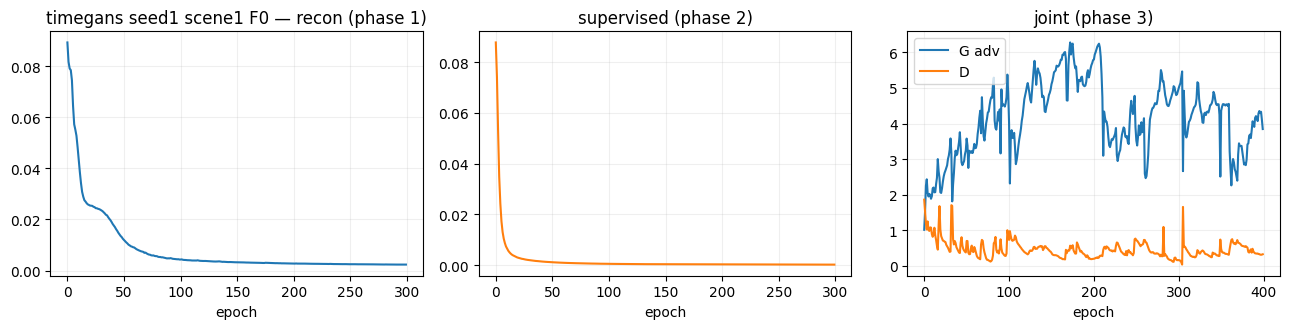

In [4]:
# Inspect one class's three-phase curves (re-train WITHOUT saving, for tuning).
# Healthy: recon falls (phase 1), supervised falls (phase 2), joint G/D wobble
# into an equilibrium (phase 3). If recon doesn't fall, nothing downstream matters.
SEED, SCENE, CLS = SEEDS[0], SCENES[0], 0
gans, hist = build_scene(SEED, SCENE, save=False, verbose=True)
fig = gan.plot_timegan_history(hist[CLS], title=f"timegans seed{SEED} scene{SCENE} F{CLS}")
plt.show()
